<a href="https://colab.research.google.com/github/abdullaawad/UK-Clinical-Commissioning-Groups-analysis/blob/main/UK_CCG_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/CCG Data.csv')

In [3]:
df.head()

,Parent Code,Parent Name,CCG Code,CCG Name,Population in Area (under 75yrs),Population in Area (75yrs and above),Number of stroke mortalities (under 75 yrs),Number of stroke mortalities (75 yrs and above),Number of Heart Disease mortalities (under 75 yrs),Number of Heart Disease mortalities (over 75 yrs),Number of patients with Atrial Fibrillation (all ages),Number of stroke patients whose last lood pressure reading was under 140/90 mmHg (under 80 yrs),Number of stroke patients where an anti-platelet agent or an anti-coagulant was taken (all ages)
0,E92000001,England,E38000006,NHS Barnsley CCG,226307,21764,46,128,111,252,4946,2740,3765
1,E92000001,England,E38000007,NHS Basildon And Brentwood CCG,241948,22852,17,77,65,145,4579,2223,3603
2,E92000001,England,E38000008,NHS Bassetlaw CCG,106280,12000,22,42,54,110,2841,1107,1833
3,E92000001,England,E38000014,NHS Blackburn With Darwen CCG,140857,9173,27,37,80,187,2507,1487,1817
4,E92000001,England,E38000015,NHS Blackpool CCG,125122,13259,26,64,84,187,3900,1859,2690


### 3. Add an Exploratory Data Analysis (EDA) Section:

## Dataset shape, column types, and null counts in a clean summary
## Distribution plots for mortality figures
## A correlation heatmap of the numeric columns

In [4]:
df.shape

(106, 13)

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Population in Area (under 75yrs),106.0,487590.066038,413068.129620,99764.0,201145.75,314667.5,644978.00,1982539.0
Population in Area (75yrs and above),106.0,45901.801887,35265.554576,9173.0,18337.00,35189.5,65788.50,170323.0
Number of stroke mortalities (under 75 yrs),106.0,58.518868,43.899502,7.0,29.00,42.5,76.00,222.0
Number of stroke mortalities (75 yrs and above),106.0,203.264151,159.091486,33.0,79.75,135.5,281.75,777.0
Number of Heart Disease mortalities (under 75 yrs),106.0,167.669811,115.759580,42.0,86.25,130.0,225.75,630.0
Number of Heart Disease mortalities (over 75 yrs),106.0,345.811321,230.878451,86.0,186.25,265.5,462.75,1262.0
Number of patients with Atrial Fibrillation (all ages),106.0,10046.518868,7496.678803,2381.0,4210.75,7530.5,14428.50,38860.0
Number of stroke patients whose last lood pressure reading was under 140/90 mmHg (under 80 yrs),106.0,4237.886792,2959.965020,965.0,1906.75,3102.5,5891.75,13089.0
Number of stroke patients where an anti-platelet agent or an anti-coagulant was taken (all ages),106.0,6471.886792,4741.145203,1487.0,2762.75,4615.5,8916.25,23390.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 13 columns):
 #   Column                                                                                            Non-Null Count  Dtype 
---  ------                                                                                            --------------  ----- 
 0   Parent Code                                                                                       106 non-null    object
 1   Parent Name                                                                                       106 non-null    object
 2   CCG Code                                                                                          106 non-null    object
 3   CCG Name                                                                                          106 non-null    object
 4   Population in Area (under 75yrs)                                                                  106 non-null    int64 
 5   Populati

In [26]:
# I noticed the heart mortality column had a space between two words, so i removed it to avoid confusion and future errors

df.rename(columns={'Number of  Heart Disease mortalities (over 75 yrs)': 'Number of Heart Disease mortalities (over 75 yrs)'}, inplace=True)
df.rename(columns={'Number of  Heart Disease mortalities (under 75 yrs)': 'Number of Heart Disease mortalities (under 75 yrs)'}, inplace=True)

In [4]:
# I checked for any missing data
df.isna().sum()

,0
Parent Code,0
Parent Name,0
CCG Code,0
CCG Name,0
Population in Area (under 75yrs),0
Population in Area (75yrs and above),0
Number of stroke mortalities (under 75 yrs),0
Number of stroke mortalities (75 yrs and above),0
Number of Heart Disease mortalities (under 75 yrs),0
Number of Heart Disease mortalities (over 75 yrs),0


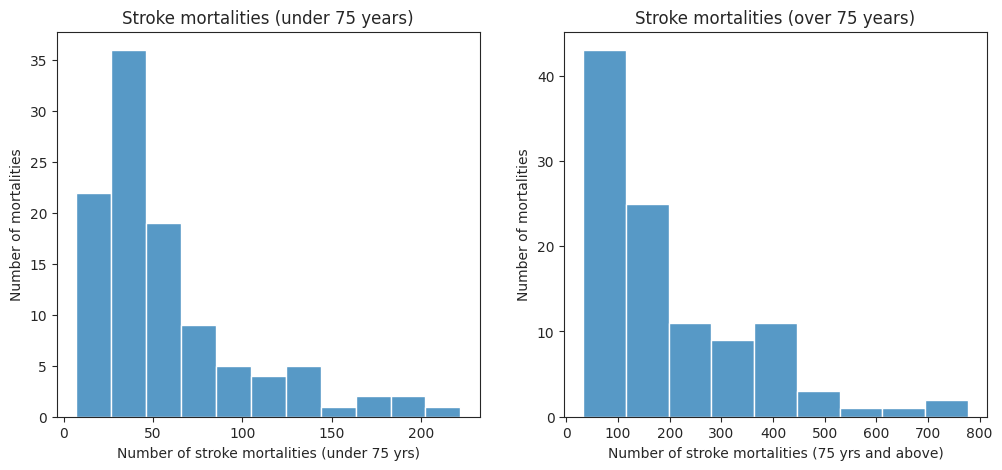

In [71]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

str1=sns.histplot(data=df, x='Number of stroke mortalities (under 75 yrs)', ax=ax[0])
str2=sns.histplot(data=df, x='Number of stroke mortalities (75 yrs and above)', ax=ax[1])
str1.set_title('Stroke mortalities (under 75 years)')
str2.set_title('Stroke mortalities (over 75 years)')
str1.set_ylabel('Number of mortalities')
str2.set_ylabel('Number of mortalities')
plt.show()

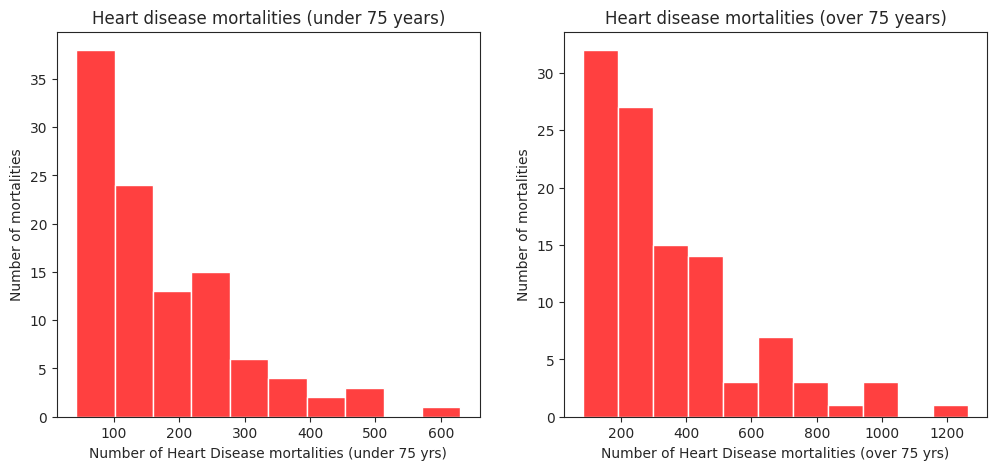

In [70]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

hd1 = sns.histplot(data=df, x='Number of Heart Disease mortalities (under 75 yrs)', ax=ax[0], color='r')
hd2 = sns.histplot(data=df, x='Number of Heart Disease mortalities (over 75 yrs)', ax=ax[1], color='r')
hd1.set_title('Heart disease mortalities (under 75 years)')
hd2.set_title('Heart disease mortalities (over 75 years)')
hd1.set_ylabel('Number of mortalities')
hd2.set_ylabel('Number of mortalities')
plt.show()

In [33]:
# I created new columns to showcase the values that we need to estimate the mortality rate

df['Total Population'] = df['Population in Area (under 75yrs)'] + df['Population in Area (75yrs and above)']
df['Total Number of Stroke mortalities'] = df['Number of stroke mortalities (under 75 yrs)'] + df['Number of stroke mortalities (75 yrs and above)']
df['Total Number of Heart Disease mortalities'] = df['Number of Heart Disease mortalities (under 75 yrs)'] + df['Number of Heart Disease mortalities (over 75 yrs)']

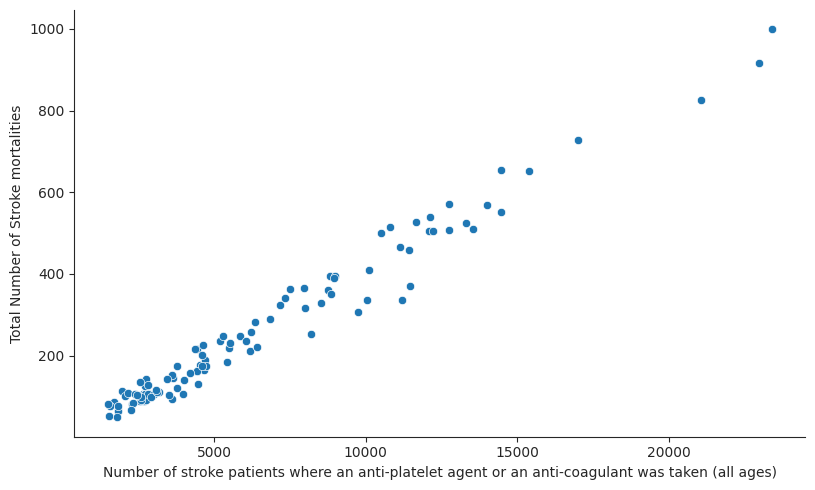

In [77]:
sns.relplot(data=df, x='Number of stroke patients where an anti-platelet agent or an anti-coagulant was taken (all ages)',
             y='Total Number of Stroke mortalities', kind='scatter', height=5, aspect=1.65)

<Axes: >

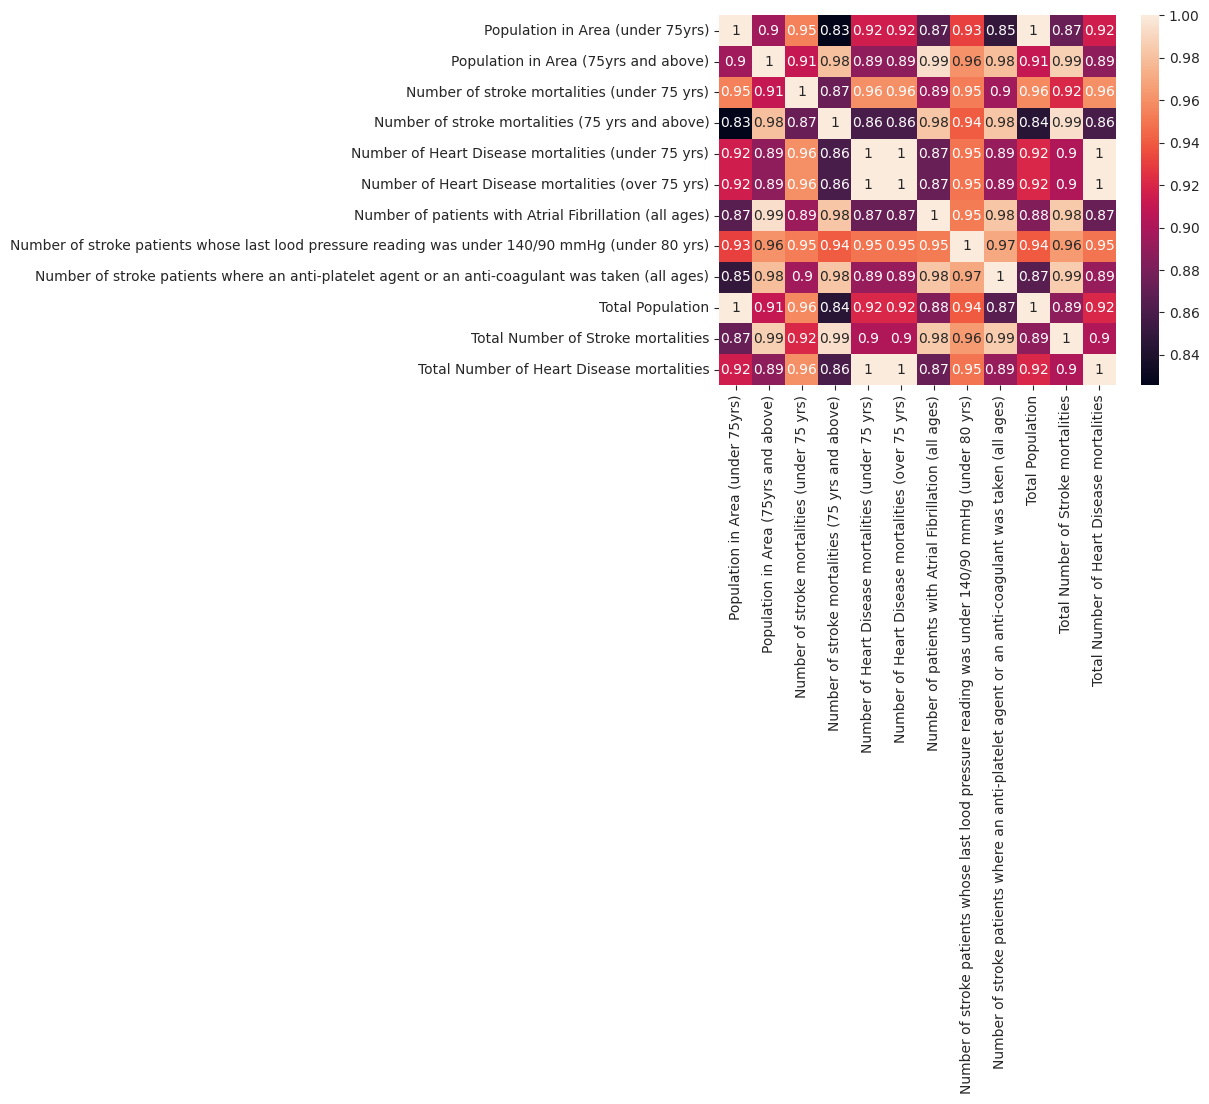

In [73]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Task:  Identify the 5 Clinical Commissioning Groups (CCGs) with the greatest mortality rates from heart disease and strokes combined. You should consider patients of all ages when calculating this. Please create a chart showing these 5 CCGs and their associated rates, be sure to include a title, axes labels &source and format the chart to be as clear as possible for someone picking it up for the first time.

In [58]:
# I grouped all of the new columns and relavent ones into a new data frame to work on.

new_df = df[['CCG Name', 'Total Population', 'Total Number of Stroke mortalities', 'Total Number of Heart Disease mortalities']].copy()

In [59]:
# I calculated the mortality rate using a simple formula

new_df['Mortality Rate'] = (new_df['Total Number of Stroke mortalities'] + new_df['Total Number of Heart Disease mortalities']) / new_df['Total Population'] * 100

In [64]:
top_5_CCG_mortality_rates = new_df.sort_values(by='Mortality Rate', ascending=False).head(5)

In [65]:
top_5_CCG_mortality_rates

,CCG Name,Total Population,Total Number of Stroke mortalities,Total Number of Heart Disease mortalities,Mortality Rate
4,NHS Blackpool CCG,138381,90,271,0.260874
45,NHS South Sefton CCG,159713,113,268,0.238553
32,NHS North East Lincolnshire CCG,159364,106,274,0.238448
67,NHS North Cumbria CCG,319669,230,517,0.233679
74,NHS Fylde & Wyre CCG,195906,144,306,0.229702


/tmp/ipykernel_31113/1350147748.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bar_chart.set_xticklabels(bar_chart.get_xticklabels(), rotation=30, horizontalalignment='right')


<Axes: title={'center': 'Top 5 Clinical Commissioning Groups with the greatest mortality rates from heart disease and strokes combined'}, xlabel='Clinical Commissioning Groups', ylabel='Mortality Rate'>

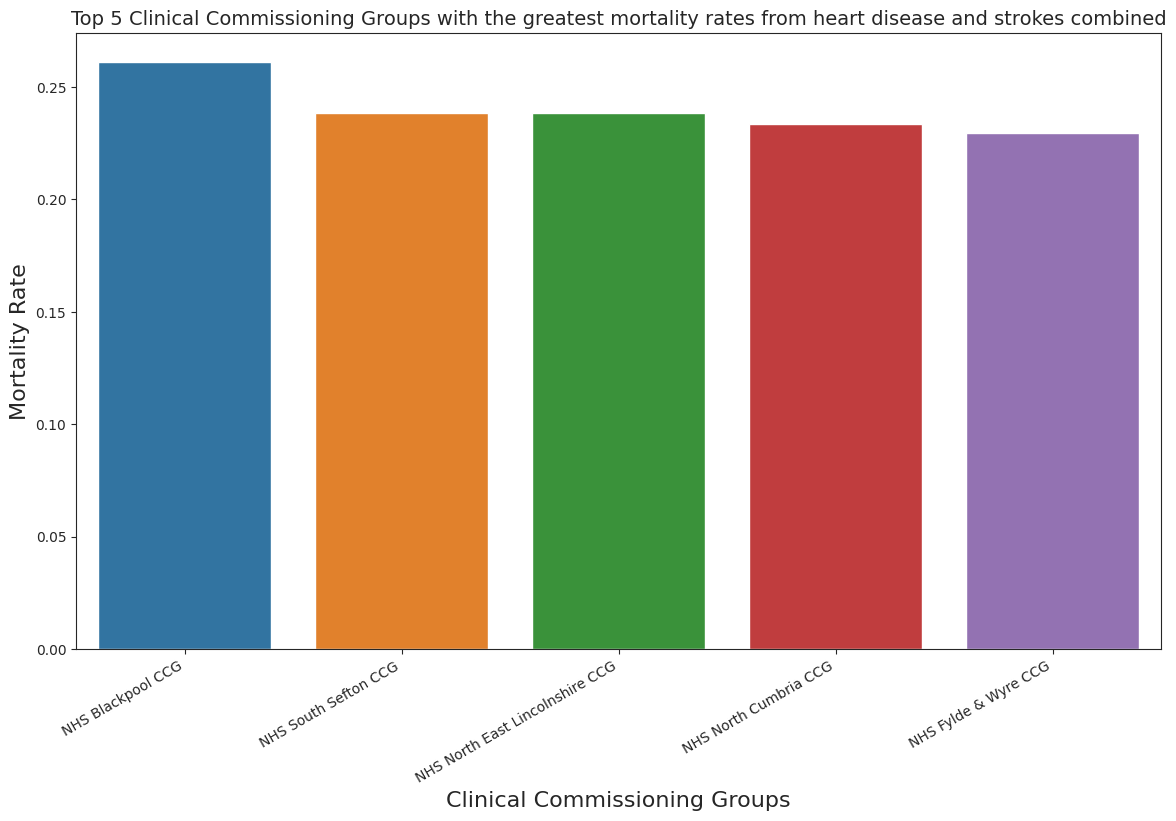

In [68]:
# This bar plot that shows the top 5 greatest mortality rates in descending order per CCG.
sns.set_style('ticks')

plt.figure(figsize=(14,8))
bar_chart = sns.barplot(x='CCG Name', y='Mortality Rate', data=top_5_CCG_mortality_rates, hue='CCG Name')
bar_chart.set_title('Top 5 Clinical Commissioning Groups with the greatest mortality rates from heart disease and strokes combined', fontsize=14)
bar_chart.set_xlabel('Clinical Commissioning Groups', fontsize=16)
bar_chart.set_ylabel('Mortality Rate', fontsize=16)
bar_chart.set_xticklabels(bar_chart.get_xticklabels(), rotation=30, horizontalalignment='right')
bar_chart